# Fractional Brownian Motion Parameter Estimation Using Variance Aggregation

Consider a time series of $n$, identically distributed samples,</br>

$
\begin{align}
X_1, X_2,X_3,\ldots,X_n
\end{align}
\tag{1}
$

Divide the series into $d$ smaller series of length $m$ where $md=n$.\ and let, $k = 0,1,2,3,\ldots,d-1$ and define the aggregated sum by,

$
\begin{align}
X_k^m &= \frac{1}{m}\left( X_{km+1} + X_{km+2} + \cdots + X_{km+m-1} + X_{km+m} \right) \\
&= \frac{1}{m} \left( X_{km+1} + \cdots + X_{(k+1)m} \right) \\
&= \frac{1}{m} \sum_{i=km+1}^{(k+1)m} X_i
\end{align}
\tag{2}
$

The aggregated mean is given by,

$
\begin{align}
\text{E}[X^m] &= \frac{1}{d}\sum_{i=1}^d X_i^m \\
&= \frac{1}{dm} \sum_{i=1}^d \sum_{j=im+1}^{(k+1)i} X_j \\
&= \frac{1}{n} \sum_{i=1}^n X_i
\end{align}
\tag{3}
$

and the aggregated variance by,

$
\begin{align}
\text{Var}[X^m] = \frac{1}{d} \sum_{i=1}^d\left( X^m_i - \text{E}[X^m] \right)^2
\end{align}
\tag{4}
$

This method makes use of the self similarity of fractional brownian motion. Consider the aggregated process,

$
\begin{align}
X_0^m = \frac{1}{m} \sum_{i=1}^m X_i
\end{align}
\tag{5}
$

From self similarity of fractional brownian motion,

$
\begin{align}
X_{ai} \sim a^H X_i
\end{align}
\tag{6}
$

Since the distribution of the sum of Gaussian random variables is the distribution of the last it follows that,</br> 

$
\begin{align}
X_0^m \sim \frac{1}{m} X_m \sim \frac{m^H}{m} X_1 = m^{H-1} X_1
\end{align}
\tag{7}
$

For fractional brownian noise,

$
\begin{align}
&\text{E}[\Delta Z^H_t] = 0 \\
&\text{Var}[\Delta Z^H_t] = \Delta t^{2H}
\end{align}
\tag{8}
$

$X_1$ is a single increment of brownian motion it follows that,

$
\begin{align}
\text{Var}[X_1] = \Delta t^{2H} = \sigma^2
\end{align}
\tag{9}
$

so,

$
\begin{align}
\text{Var}[X_0^m] = \text{Var}[m^{H-1} X_1] = m^{2(H-1)}\text{Var}[X_1] = \sigma^2 m^{2(H-1)}
\end{align}
\tag{10}
$

From stationarity of it follows that,

$
\begin{align}
\text{Var}[X_k^m] = \sigma^2 m^{2(H-1)}
\end{align}
\tag{11}
$

It follows that $H$ can be determined by using OLS on $\text{Var}[X_k^m]$ as a function of $m$.

## Imports

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import fbm, stats
from lib.plots import variance_agg, stack, curve
from lib.utils import create_parameter_scan

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
Δt = 1.0
npts = 2**10
nagg = 100

def var_agg_comparison(t, fbm_noise, H):
    m_vals = [1, 10, 50]
    title = f"Aggregated Fractional Brownian Noise: Δt={Δt}, H={H}"
    labels = [f"m={m}" for m in m_vals]
    params = [{"m": m} for m in m_vals]
    func = lambda **kwargs: stats.compute_agg(t, fbm_noise, **kwargs)
    t_scan, m_scan = create_parameter_scan(func, *params)
    ylabels = [r"$X^1$", r"$X^{10}$", r"$X^{50}$"]
    stack(m_scan, t_scan, ylim=(-3.5, 3.5), ylabels=ylabels, xlabel=r"$t$", title=title, labels=labels)

## Simulation $H=0.8$

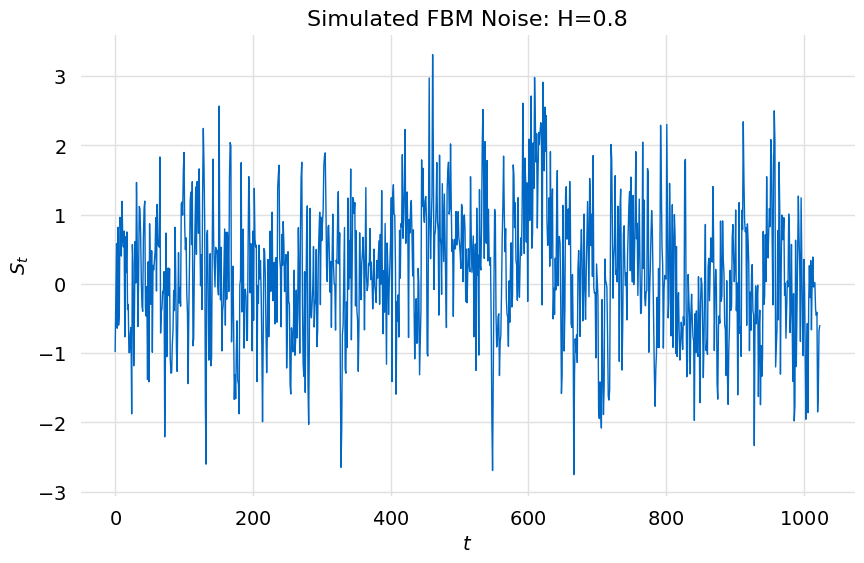

In [3]:
H = 0.8
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

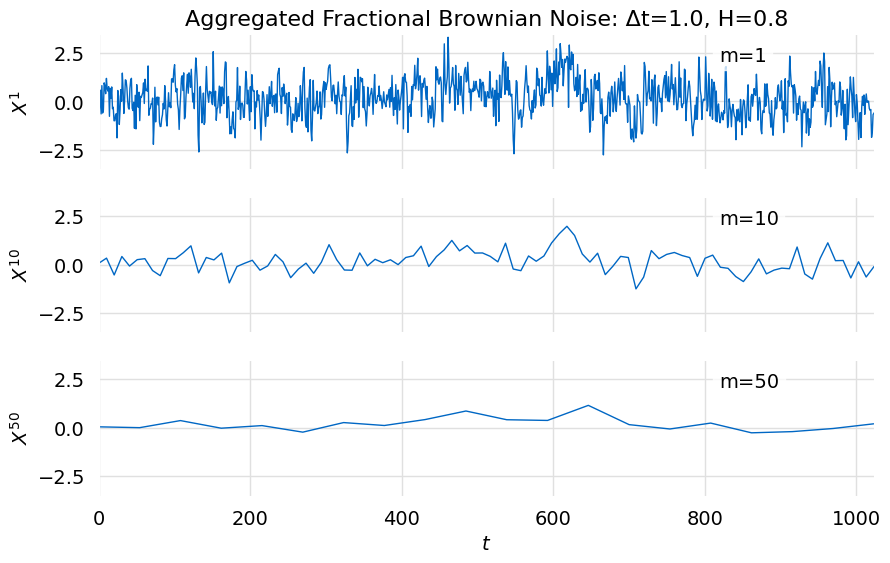

In [4]:
var_agg_comparison(t, fbm_noise, H)

In [5]:
m_vals, agg_var = stats.compute_agg_var(fbm_noise, m_max=nagg, npts=nagg)

In [6]:
result, result_model = fbm.compute_H_estimate_variance_aggregation(m_vals, agg_var)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.984
Method:                 Least Squares   F-statistic:                     6272.
Date:                Sun, 03 Sep 2023   Prob (F-statistic):           1.19e-90
Time:                        17:56:17   Log-Likelihood:                 182.32
No. Observations:                 100   AIC:                            -360.6
Df Residuals:                      98   BIC:                            -355.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0426      0.008      5.432      0.000       0.027       0.058
x1            -0.5361      0.007    -79.194      0.000      -0.550      -0.523
==============================================================================
Omnibus:                       23.445   Durbin-Watson:                   1.936
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               37.748
Skew:                          -1.017   Prob(JB):                     6.35e-09
Kurtosis:                       5.219   Cond. No.                         3.75
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [7]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS_SING_VAR",
   "const": {
      "est": 0.04257306102877452,
      "err": 0.00783680264998144,
      "est_label": null,
      "err_label": null,
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "bc578e3b-4a80-462d-97d6-076e61823f75",
      "param_type": "OLS_CONST"
   },
   "param": {
      "est": -0.53612838221507,
      "err": 0.006769796265036854,
      "est_label": null,
      "err_label": null,
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "bc578e3b-4a80-462d-97d6-076e61823f75",
      "param_type": "OLS_PARAM"
   },
   "r2": 0.9846146992399715,
   "transform": {
      "model": "$\\sigma^2 m^{2\\left(H-1\\right)}$",
      "param": {
         "est": 0.731935808892465,
         "err": 0.003384898132518427,
         "est_label": "$\\hat{\u0397}$",
         "err_label": "$\\sigma_{\\hat{\u0397}}$",
         "row": 0,
         "column": 0,
         "order": 0,
         "est_id": "bc578e3b-4a80-462d-97d6-076e61823f75",
     

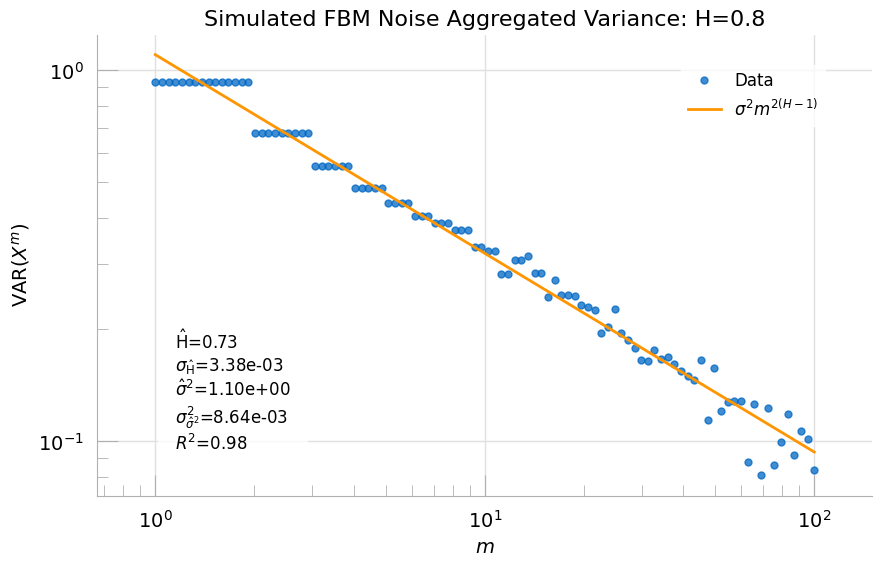

In [8]:
variance_agg(agg_var, result_model, m_vals, title=f"Simulated FBM Noise Aggregated Variance: H={H}")

## Simulation $H=0.6$

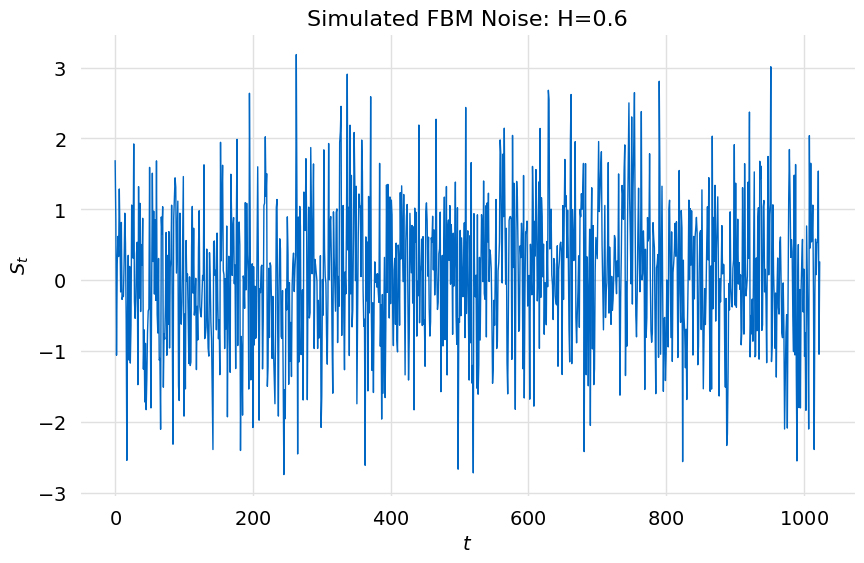

In [9]:
H = 0.6
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

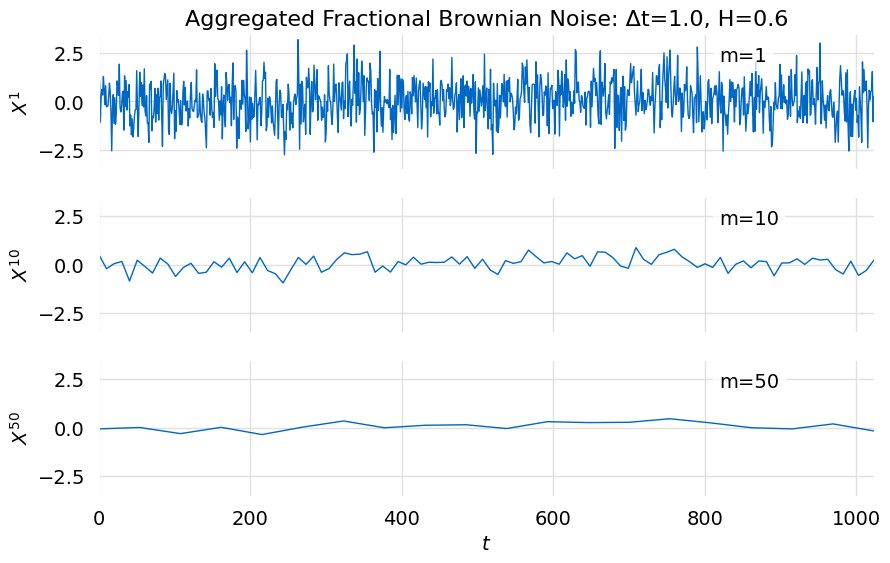

In [10]:
var_agg_comparison(t, fbm_noise, H)

In [11]:
m_vals, agg_var = stats.compute_agg_var(fbm_noise, m_max=nagg, npts=nagg)

In [12]:
result, result_model = fbm.compute_H_estimate_variance_aggregation(m_vals, agg_var)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     6590.
Date:                Sun, 03 Sep 2023   Prob (F-statistic):           1.09e-91
Time:                        17:56:18   Log-Likelihood:                 137.72
No. Observations:                 100   AIC:                            -271.4
Df Residuals:                      98   BIC:                            -266.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0773      0.012      6.315      0.000       0.053       0.102
x1            -0.8585      0.011    -81.179      0.000      -0.879      -0.837
==============================================================================
Omnibus:                        8.475   Durbin-Watson:                   0.826
Prob(Omnibus):                  0.014   Jarque-Bera (JB):                8.387
Skew:                           0.699   Prob(JB):                       0.0151
Kurtosis:                       3.243   Cond. No.                         3.75
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [13]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS_SING_VAR",
   "const": {
      "est": 0.0773035449562358,
      "err": 0.0122416351837012,
      "est_label": null,
      "err_label": null,
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "48104a8b-77e4-43e0-bc6a-057a0b3d4dc9",
      "param_type": "OLS_CONST"
   },
   "param": {
      "est": -0.8584605235780475,
      "err": 0.01057489640175645,
      "est_label": null,
      "err_label": null,
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "48104a8b-77e4-43e0-bc6a-057a0b3d4dc9",
      "param_type": "OLS_PARAM"
   },
   "r2": 0.9853469896966704,
   "transform": {
      "model": "$\\sigma^2 m^{2\\left(H-1\\right)}$",
      "param": {
         "est": 0.5707697382109762,
         "err": 0.005287448200878225,
         "est_label": "$\\hat{\u0397}$",
         "err_label": "$\\sigma_{\\hat{\u0397}}$",
         "row": 0,
         "column": 0,
         "order": 0,
         "est_id": "48104a8b-77e4-43e0-bc6a-057a0b3d4dc9",
     

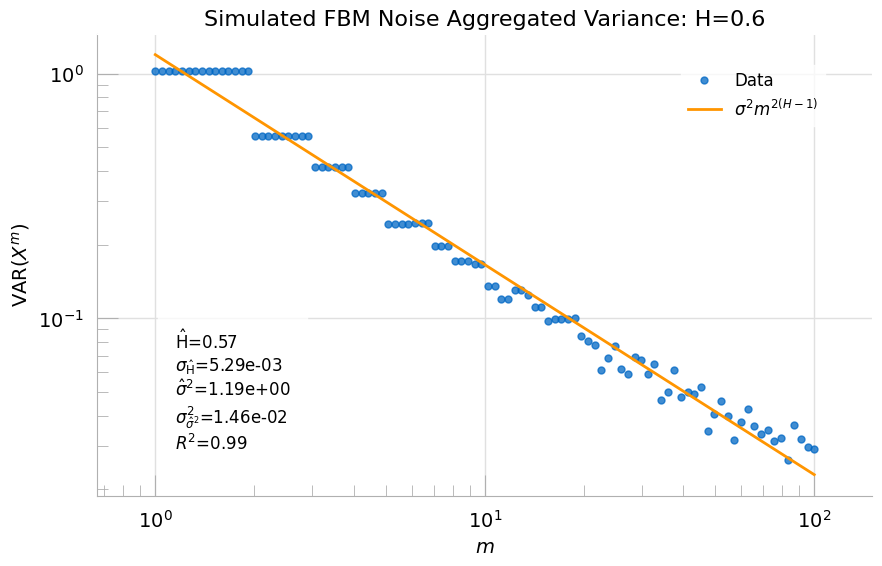

In [14]:
variance_agg(agg_var, result_model, m_vals, title=f"Simulated FBM Noise Aggregated Variance: H={H}")

## Simulation $H=0.4$

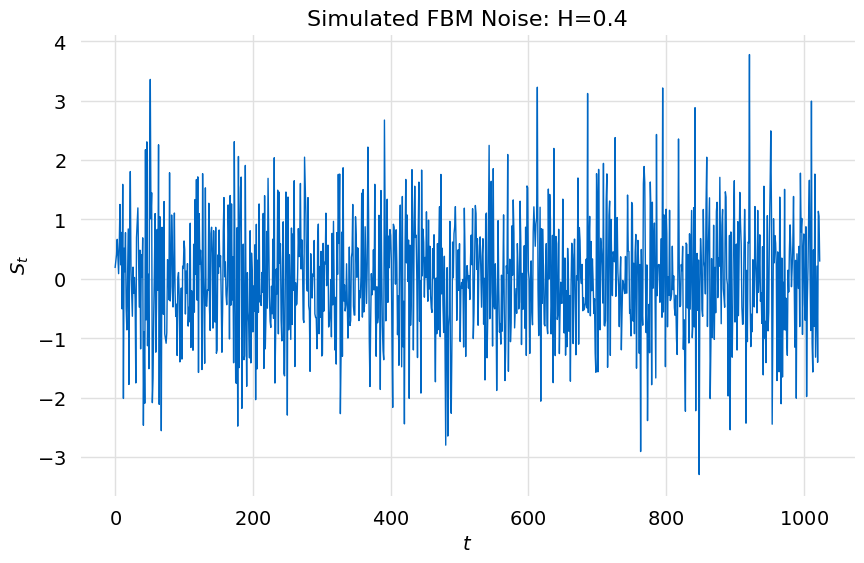

In [15]:
H = 0.4
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

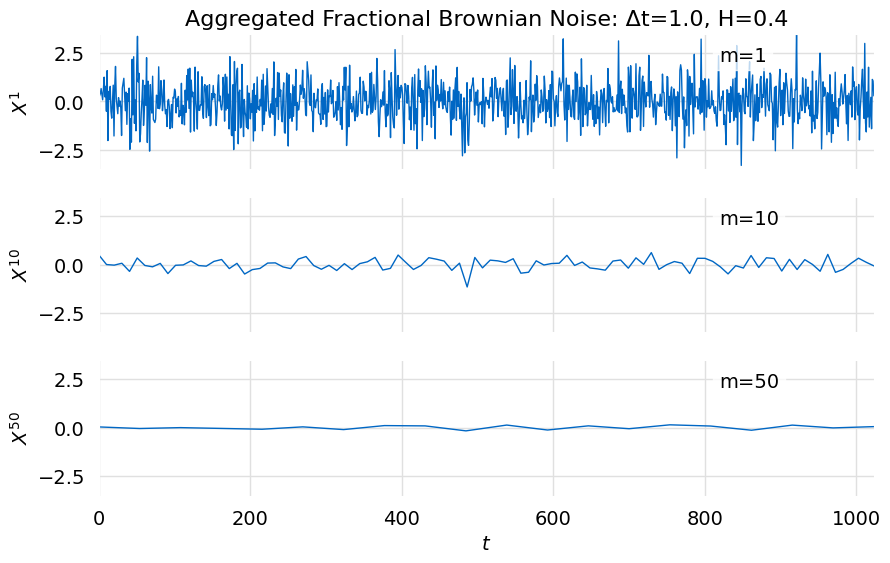

In [16]:
var_agg_comparison(t, fbm_noise, H)

In [17]:
m_vals, agg_var = stats.compute_agg_var(fbm_noise, m_max=nagg, npts=nagg)

In [18]:
result, result_model = fbm.compute_H_estimate_variance_aggregation(m_vals, agg_var)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                     5118.
Date:                Sun, 03 Sep 2023   Prob (F-statistic):           2.14e-86
Time:                        17:56:19   Log-Likelihood:                 84.229
No. Observations:                 100   AIC:                            -164.5
Df Residuals:                      98   BIC:                            -159.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1636      0.021      7.827      0.000       0.122       0.205
x1            -1.2915      0.018    -71.538      0.000      -1.327      -1.256
==============================================================================
Omnibus:                        6.212   Durbin-Watson:                   0.942
Prob(Omnibus):                  0.045   Jarque-Bera (JB):                8.356
Skew:                          -0.244   Prob(JB):                       0.0153
Kurtosis:                       4.330   Cond. No.                         3.75
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [19]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS_SING_VAR",
   "const": {
      "est": 0.1635738392708183,
      "err": 0.020899207389976728,
      "est_label": null,
      "err_label": null,
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "16ef3db9-8ce0-4793-8328-56640862eca3",
      "param_type": "OLS_CONST"
   },
   "param": {
      "est": -1.291519659337247,
      "err": 0.018053711755932778,
      "est_label": null,
      "err_label": null,
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "16ef3db9-8ce0-4793-8328-56640862eca3",
      "param_type": "OLS_PARAM"
   },
   "r2": 0.9812103299755435,
   "transform": {
      "model": "$\\sigma^2 m^{2\\left(H-1\\right)}$",
      "param": {
         "est": 0.35424017033137645,
         "err": 0.009026855877966389,
         "est_label": "$\\hat{\u0397}$",
         "err_label": "$\\sigma_{\\hat{\u0397}}$",
         "row": 0,
         "column": 0,
         "order": 0,
         "est_id": "16ef3db9-8ce0-4793-8328-56640862eca3",
  

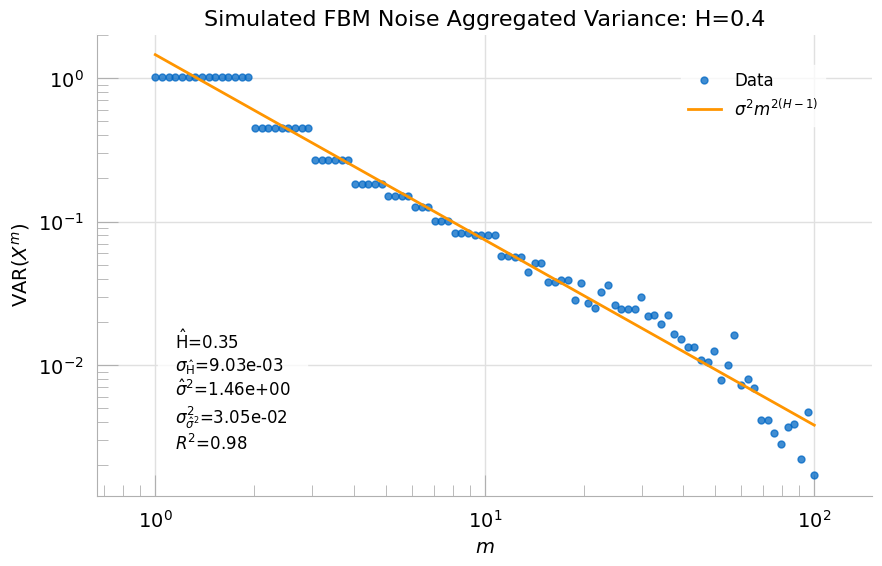

In [20]:
variance_agg(agg_var, result_model, m_vals, title=f"Simulated FBM Noise Aggregated Variance: H={H}")

## Simulation $H=0.2$

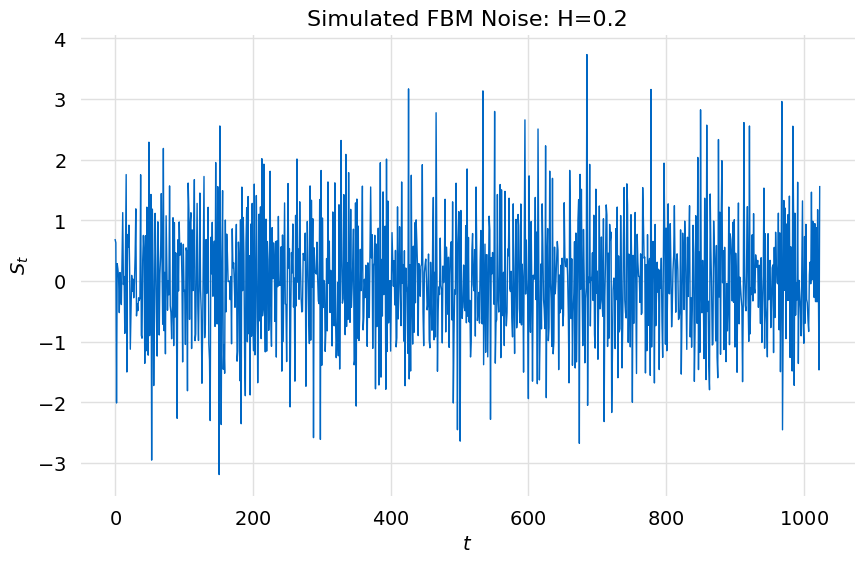

In [21]:
H = 0.2
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

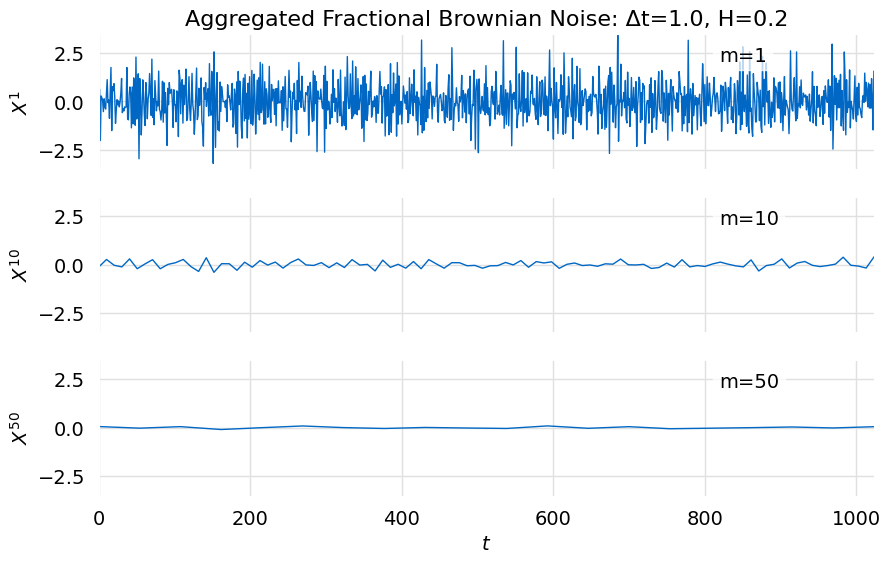

In [22]:
var_agg_comparison(t, fbm_noise, H)

In [23]:
m_vals, agg_var = stats.compute_agg_var(fbm_noise, m_max=nagg, npts=nagg)

In [24]:
result, result_model = fbm.compute_H_estimate_variance_aggregation(m_vals, agg_var)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                 1.006e+04
Date:                Sun, 03 Sep 2023   Prob (F-statistic):          1.36e-100
Time:                        17:56:20   Log-Likelihood:                 91.470
No. Observations:                 100   AIC:                            -178.9
Df Residuals:                      98   BIC:                            -173.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1825      0.019      9.389      0.000       0.144       0.221
x1            -1.6847      0.017   -100.324      0.000      -1.718      -1.651
==============================================================================
Omnibus:                        8.182   Durbin-Watson:                   1.255
Prob(Omnibus):                  0.017   Jarque-Bera (JB):                7.938
Skew:                           0.672   Prob(JB):                       0.0189
Kurtosis:                       3.313   Cond. No.                         3.75
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [25]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS_SING_VAR",
   "const": {
      "est": 0.18252605069603012,
      "err": 0.01943941874281036,
      "est_label": null,
      "err_label": null,
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "531b520a-1409-4029-bb30-da7077553fae",
      "param_type": "OLS_CONST"
   },
   "param": {
      "est": -1.684708284311557,
      "err": 0.016792678121079988,
      "est_label": null,
      "err_label": null,
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "531b520a-1409-4029-bb30-da7077553fae",
      "param_type": "OLS_PARAM"
   },
   "r2": 0.9903570838069838,
   "transform": {
      "model": "$\\sigma^2 m^{2\\left(H-1\\right)}$",
      "param": {
         "est": 0.15764585784422147,
         "err": 0.008396339060539994,
         "est_label": "$\\hat{\u0397}$",
         "err_label": "$\\sigma_{\\hat{\u0397}}$",
         "row": 0,
         "column": 0,
         "order": 0,
         "est_id": "531b520a-1409-4029-bb30-da7077553fae",
  

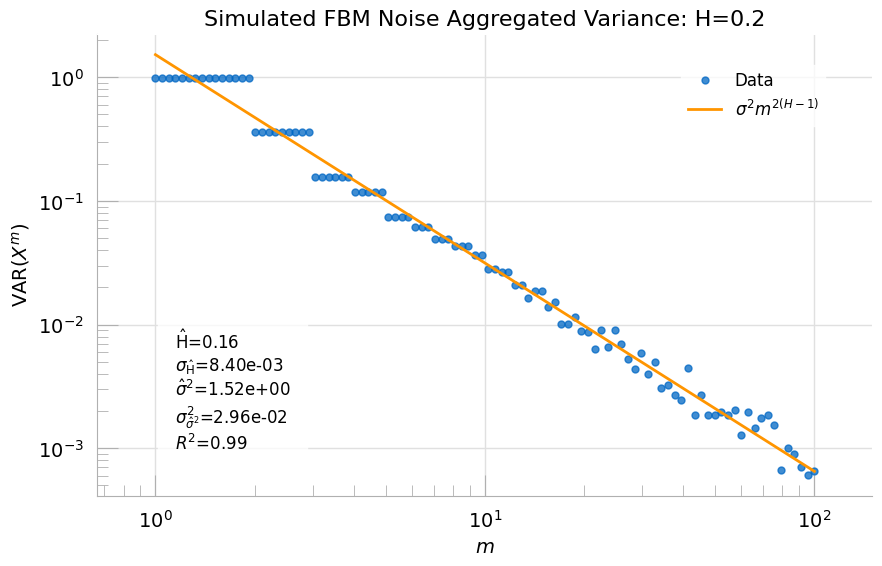

In [26]:
variance_agg(agg_var, result_model, m_vals, title=f"Simulated FBM Noise Aggregated Variance: H={H}")